In [11]:
import pandas as pd
from pathlib import Path
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, Lipinski, rdMolDescriptors
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')

In [12]:
# Load ROBIN library
robin_df = pd.read_csv('../robin_clean.csv')[['Smile', 'TPP']]
robin_all = robin_df['Smile'].tolist()
robin_hits = robin_df[robin_df['TPP'] == 1]['Smile'].tolist()

print(f"ROBIN all: {len(robin_all)} molecules")
print(f"ROBIN hits: {len(robin_hits)} molecules")

ROBIN all: 24501 molecules
ROBIN hits: 162 molecules


In [13]:
# Load optimized molecules from all methods (top 100 from each seed)
methods = ['graph_ga', 'gp_bo', 'reinvent', 'smiles_ga']
seeds = [0, 1, 2, 3, 5]
opt_results_base = Path('opt_results/first_run')

opt_smiles_dict = {}
for method in methods:
    opt_smiles_dict[method] = []
    for seed in seeds:
        if os.path.exists(opt_results_base / method / f'results_{method}_rnamigos2_oracle_{seed}.csv'):
            csv_path = opt_results_base / method / f'results_{method}_rnamigos2_oracle_{seed}.csv'
            df = pd.read_csv(csv_path).sort_values('rnamigos2_score', ascending=False).head(100)
            opt_smiles_dict[method].extend(df['smiles'].tolist())
    print(f"{method}: {len(opt_smiles_dict[method])} molecules")

graph_ga: 500 molecules
gp_bo: 500 molecules
reinvent: 500 molecules
smiles_ga: 500 molecules


In [14]:
# Calculate molecular properties
def calc_properties(smiles_list):
    props = []
    for smiles in smiles_list:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            props.append({
                'MW': Descriptors.MolWt(mol),
                'cLogP': Crippen.MolLogP(mol),
                'tPSA': rdMolDescriptors.CalcTPSA(mol),
                'HBD': Lipinski.NumHDonors(mol),
                'HBA': Lipinski.NumHAcceptors(mol)
            })
    return props

# Calculate for ROBIN
robin_all_props = calc_properties(robin_all)
robin_hits_props = calc_properties(robin_hits)

df_robin_all = pd.DataFrame(robin_all_props)
df_robin_all['dataset'] = 'ROBIN library'

df_robin_hits = pd.DataFrame(robin_hits_props)
df_robin_hits['dataset'] = 'ROBIN hits'

# Calculate for all optimization methods
df_list = [df_robin_all, df_robin_hits]
for method in methods:
    method_props = calc_properties(opt_smiles_dict[method])
    df_method = pd.DataFrame(method_props)
    df_method['dataset'] = method
    df_list.append(df_method)

df_all = pd.concat(df_list, ignore_index=True)
print(f"Properties calculated for {len(df_all)} molecules")

[22:20:50] Conflicting single bond directions around double bond at index 27.
[22:20:50]   BondStereo set to STEREONONE and single bond directions set to NONE.


Properties calculated for 26663 molecules


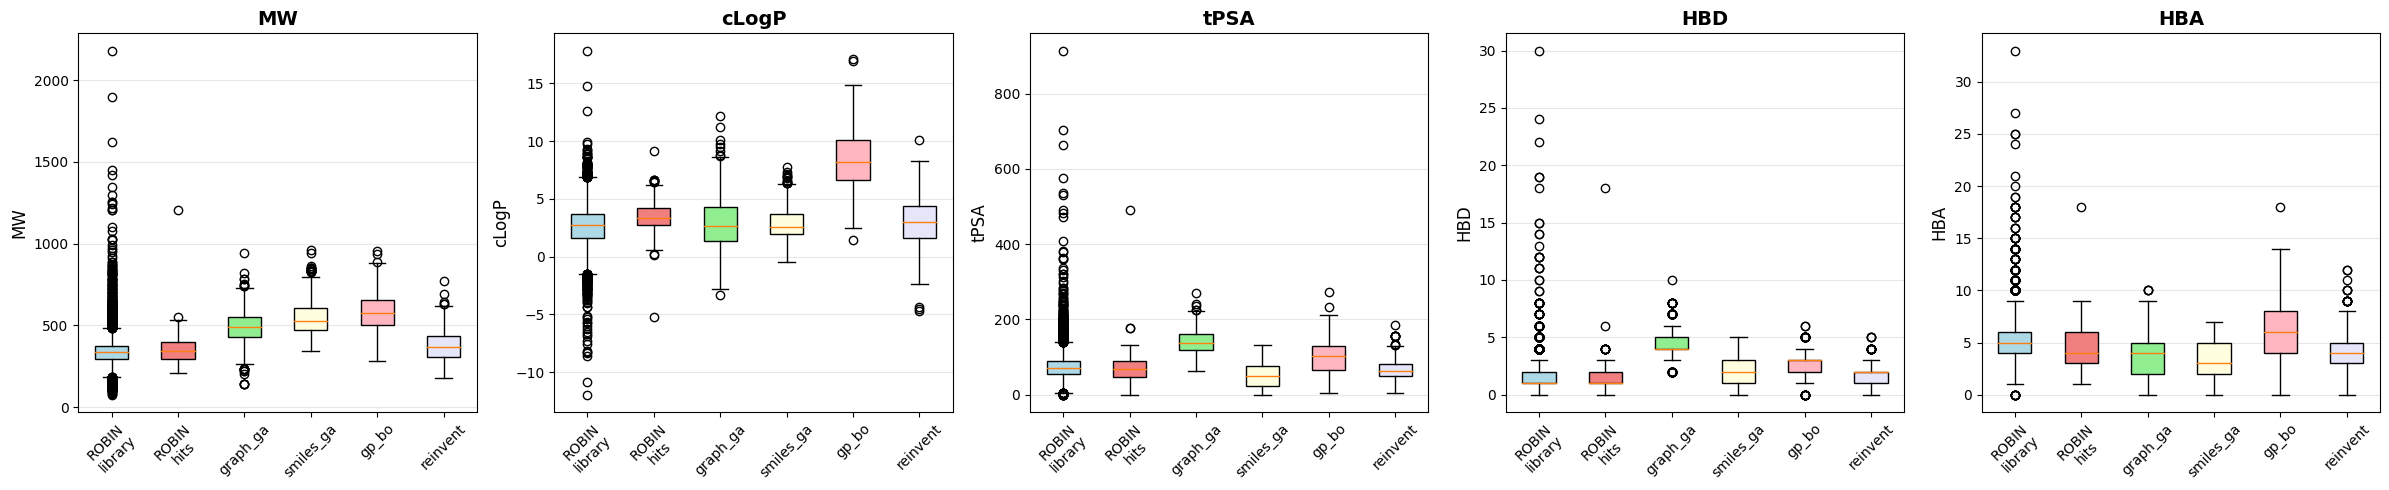

In [15]:
# Create boxplot visualization
properties = ['MW', 'cLogP', 'tPSA', 'HBD', 'HBA']
fig, axes = plt.subplots(1, 5, figsize=(24, 5))

datasets = ['ROBIN library', 'ROBIN hits', 'graph_ga', 'smiles_ga', 'gp_bo', 'reinvent']
colors = ['lightblue', 'lightcoral', 'lightgreen', 'lightyellow', 'lightpink', 'lavender']
labels = ['ROBIN\nlibrary', 'ROBIN\nhits', 'graph_ga', 'smiles_ga', 'gp_bo', 'reinvent']

for idx, prop in enumerate(properties):
    ax = axes[idx]
    data = [df_all[df_all['dataset'] == ds][prop] for ds in datasets]
    
    bp = ax.boxplot(data, labels=labels, patch_artist=True)
    
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    
    ax.set_ylabel(prop, fontsize=12)
    ax.set_title(prop, fontsize=14, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# RNA-specific features (ROBIN Paper Features)
# These are now calculated in calculate_robin_rna_features.py
# Run: python calculate_robin_rna_features.py
# Output: display_outputs/robin_rna_features.csv
# Figure: display_outputs/figures/rna_features_comparison.png

In [ ]:
# This cell has been moved to calculate_robin_rna_features.py


In [ ]:
# This cell has been moved to calculate_robin_rna_features.py

Calculating RNA features...


Exception ignored in: <function tqdm.__del__ at 0x7f4b48ca32e0>
Traceback (most recent call last):
  File "/home/wangx86/miniconda3/envs/mol-opt/lib/python3.10/site-packages/tqdm/std.py", line 1148, in __del__
    self.close()
  File "/home/wangx86/miniconda3/envs/mol-opt/lib/python3.10/site-packages/tqdm/notebook.py", line 279, in close
    self.disp(bar_style='danger', check_delay=False)
AttributeError: 'tqdm_notebook' object has no attribute 'disp'
Calculating RNA features: 100%|██████████| 162/162 [00:17<00:00,  9.14it/s]


In [ ]:
# This cell has been moved to calculate_robin_rna_features.py

Calculating RNA features: 100%|██████████| 500/500 [00:45<00:00, 10.88it/s]

RNA features calculated for 2162 molecules


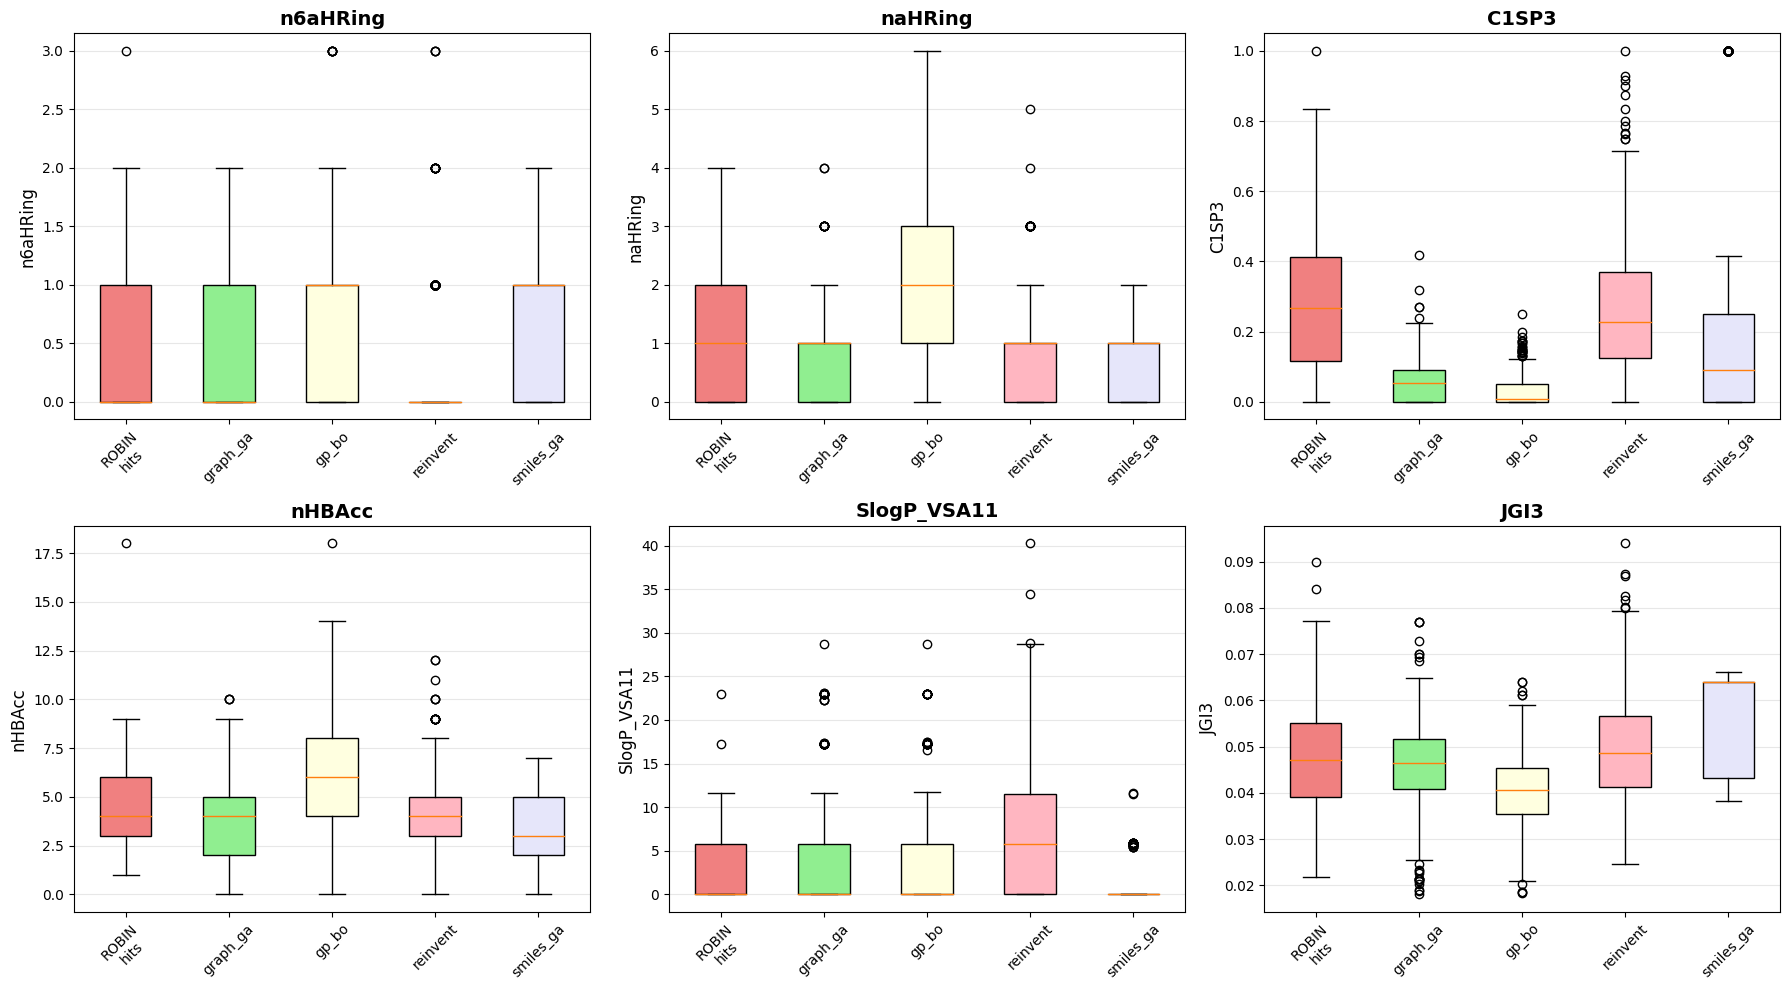

In [ ]:
# This cell has been moved to calculate_robin_rna_features.py